In [1]:
from pathlib import Path
from os import environ


IN_COLAB = False
if "DRIVE_HOME" in environ:
  ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
else:
  ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/binom2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/posterior")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Created /Users/ashrafahmed/Google Drive/My Drive/colab/outputs/waterloo-slt-reading-group/mixture/binom2d/posterior!
Using datadir=/Users/ashrafahmed/Google Drive/My Drive/colab/outputs/waterloo-slt-reading-group/mixture/binom2d/data
Using outputdir=/Users/ashrafahmed/Google Drive/My Drive/colab/outputs/waterloo-slt-reading-group/mixture/binom2d/posterior


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00
3,singular2,0.35,0.35,0.75,0.25


In [3]:
def find_truth_by_dsid(dsid: str):
    dgp = dgps.query(f"dsid=='{dsid}'")
    truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
    return truth

In [4]:
import pytensor
import pymc as pm
import numpy as np
from tqdm.notebook import tqdm
import arviz as az


n_components = 2
n_trials = 100

regimes = [50, 250, 5000]

n_draws = 2000
n_tune = 10000
posterior_samples = {}

for dsid in tqdm(dgps["dsid"].unique(), desc=f"class "):
  posterior_samples[dsid] = {}
  for regime in tqdm(regimes, desc=f"dsid={dsid}, regime "):
    posterior_data_file = Path(f"{outputdir}/posterior-{dsid}-{regime}.nc")
    if posterior_data_file.exists(): # check if this data has already been generated
        idata = az.from_netcdf(posterior_data_file)
        print(f"Loaded posterior data from {posterior_data_file}!")
    else:
      dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
      X = dataset.iloc[:, 0].to_numpy()
      # Mixture of 2 Poisson variables
      with pm.Model() as model:
        weights = pm.Dirichlet("weights", a=np.array([1, 1]))  # 2 mixture weights
        
        probs = [pm.Uniform(f"p{i}", 0, 1) for i in range(n_components)]
        components = [pm.Binomial.dist(n=100, p=p) for p in probs]
      
        like = pm.Mixture("like", w=weights, comp_dists=components, observed=X)
        idata = pm.sample(nuts_sampler="numpyro",
                          draws=n_draws,
                          chains=4,
                          max_treedepth=50,
                          tune=n_tune,
                          target_accept=0.999)  # or "blackjax"
        # posterior_samples[dsid][regime] = idata
        idata.to_netcdf(posterior_data_file)
        print(f"File {posterior_data_file} created!.")
        
    posterior_samples[dsid][regime]=idata

class :   0%|          | 0/4 [00:00<?, ?it/s]

dsid=regular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/12000 [00:00<?, ?it/s]

  0%|          | 0/12000 [00:00<?, ?it/s]

  0%|          | 0/12000 [00:00<?, ?it/s]

...

  0%|          | 0/12000 [00:00<?, ?it/s]

  0%|          | 0/12000 [00:00<?, ?it/s]

  0%|          | 0/12000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


File /Users/ashrafahmed/Google Drive/My Drive/colab/outputs/waterloo-slt-reading-group/mixture/binom2d/posterior/posterior-singular2-5000.nc created!.


In [5]:
def chain_diag(dsid="singular1", regime=5000):
  az.plot_trace(posterior_samples[dsid][regime], combined=True)

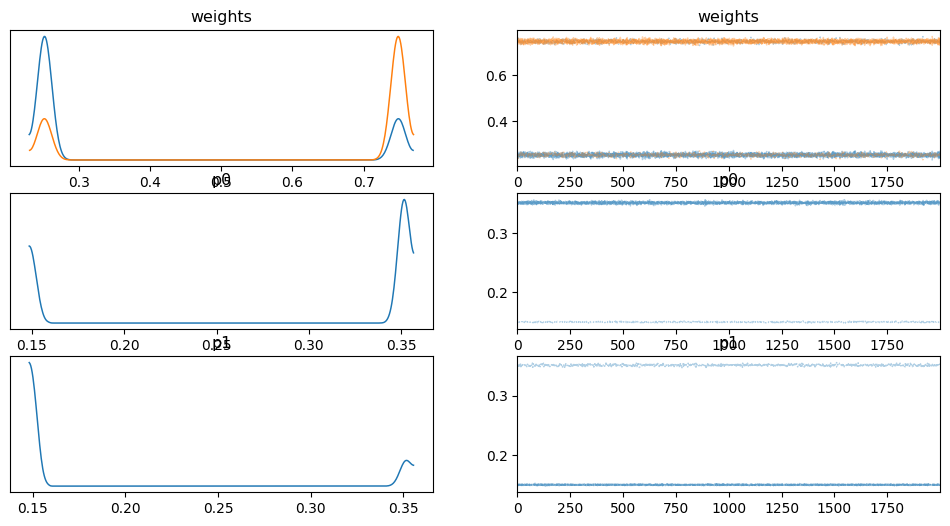

In [6]:
chain_diag("regular", 5000)

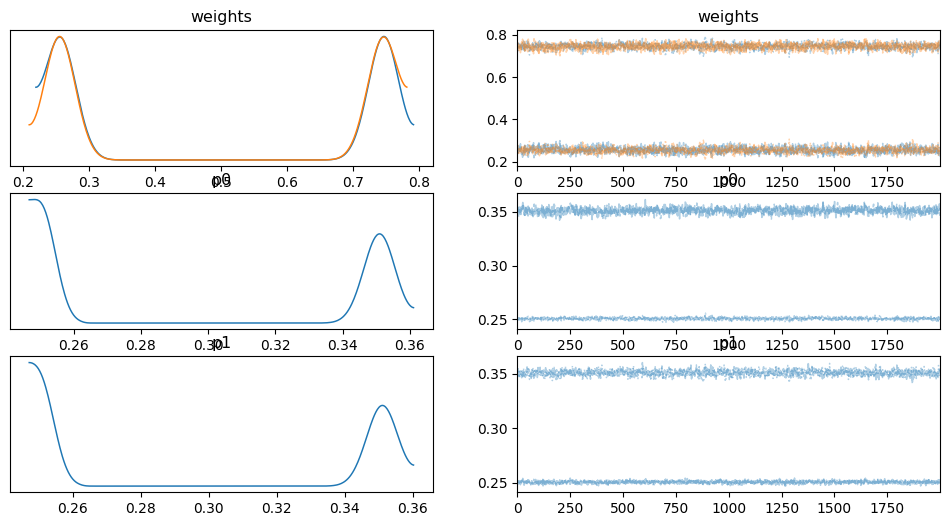

In [7]:
chain_diag("e-singular", 5000)

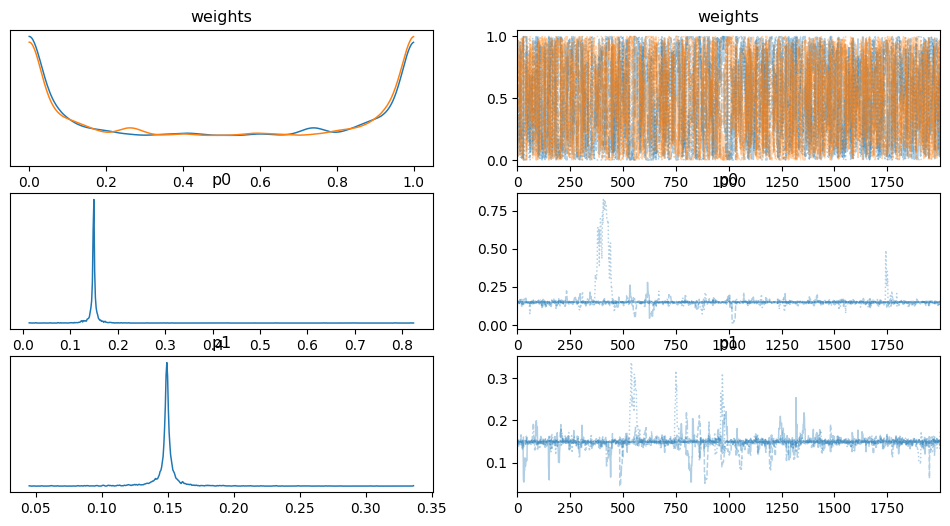

In [9]:
chain_diag("singular1", 5000)

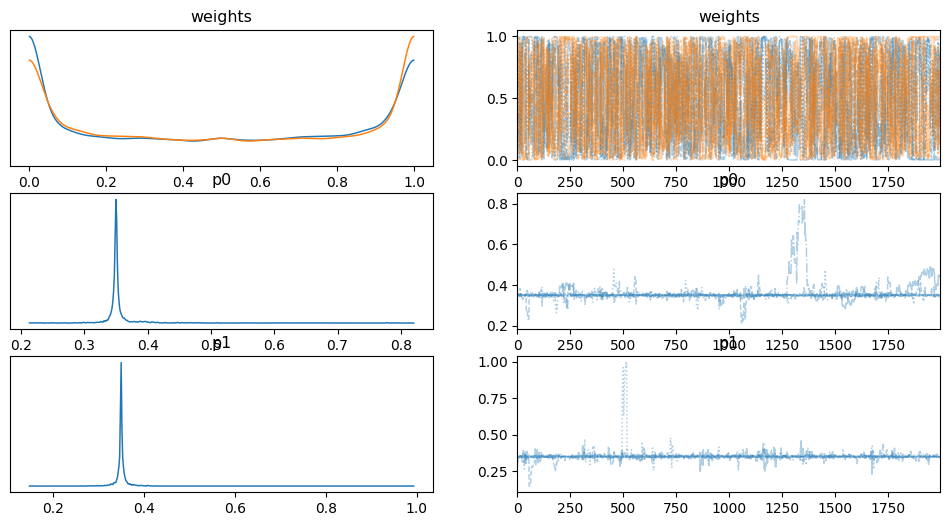

In [8]:
chain_diag("singular2", 5000)

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3d(dsid="singular1", regime=5000):
  idata = posterior_samples[dsid][regime]
  w = idata.posterior["weights"][1,:,0]
  p0 = idata.posterior["p0"][1,:]
  p1 = idata.posterior["p1"][1,:]
  
  fig = plt.figure(figsize=(12, 10))  # width, height in inches
  ax = fig.add_subplot(111, projection='3d')
  
  n_chains = idata.posterior.dims["chain"]
  n_draws = idata.posterior.dims["draw"]
  markers = ['o', '^', '.', '+']
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain,:,0]
    p0 = idata.posterior["p0"][chain,:]
    p1 = idata.posterior["p1"][chain,:]
    ax.scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)


/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_20924/1125825123.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain in range(idata.posterior.dims["chain"]):
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_20924/1125825123.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims["chain"]


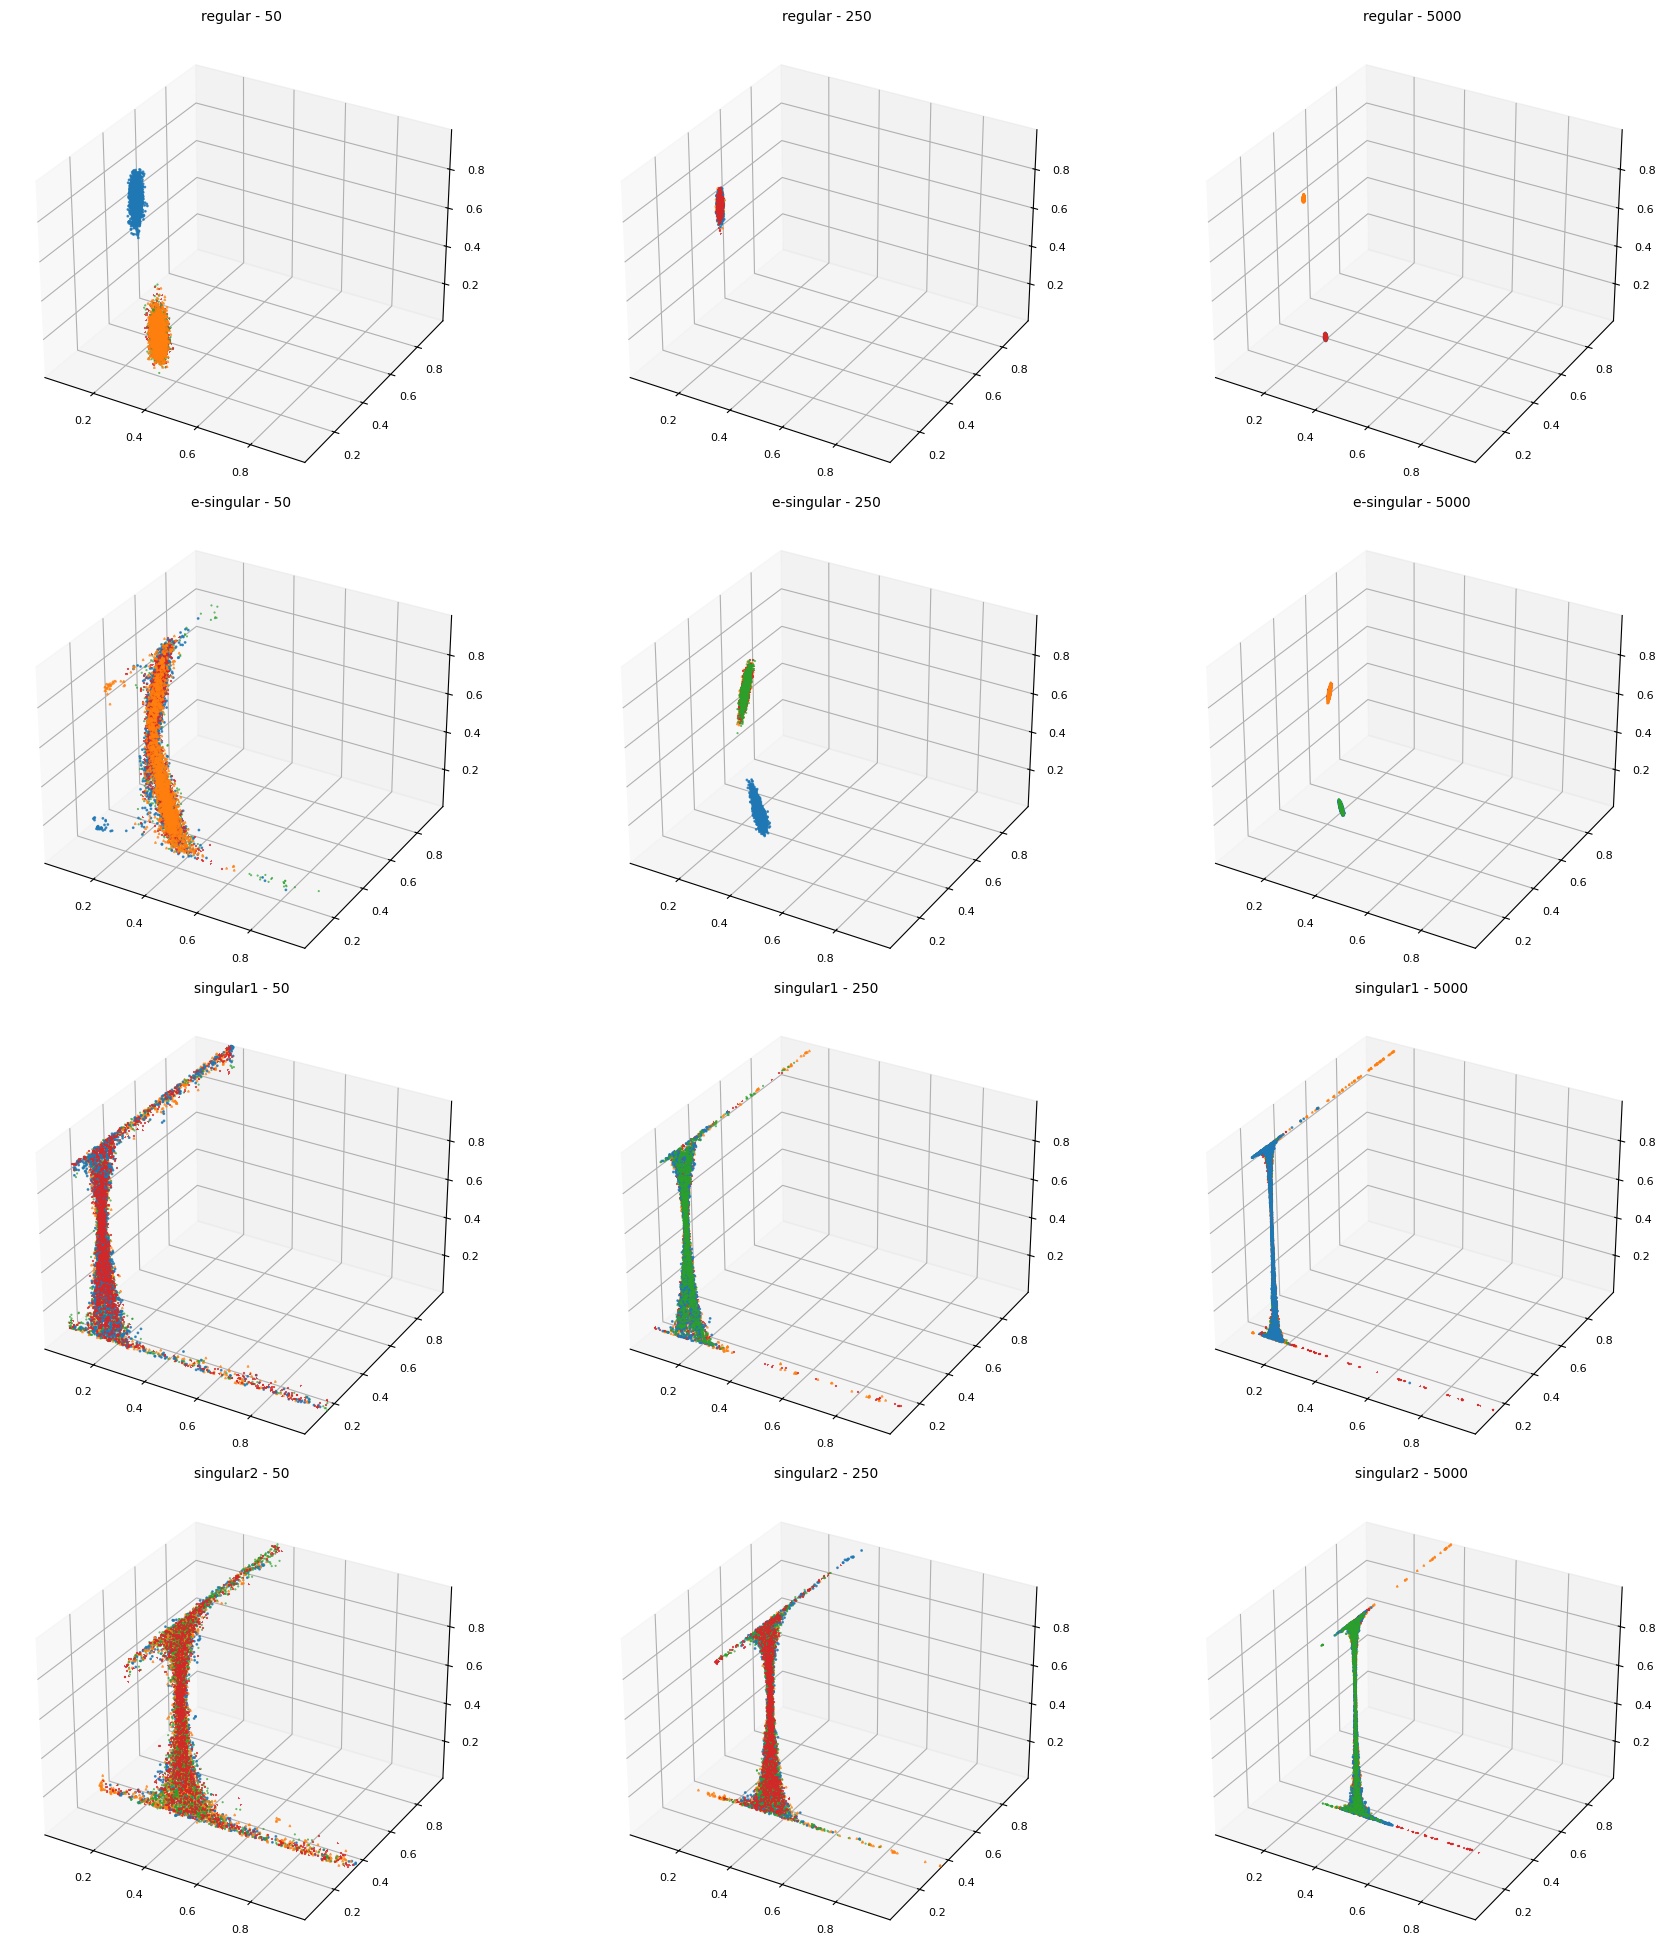

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 3, figsize=(18, 20), subplot_kw={'projection': '3d'})

# Reduce white space
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.98, top=0.98, bottom=0.02)

# First pass: collect global min/max for shared axes
all_p0, all_p1, all_w = [], [], []

for dsid, dsid_data in posterior_samples.items():
    for regime, regime_data in dsid_data.items():
        idata = posterior_samples[dsid][regime]
        for chain in range(idata.posterior.dims["chain"]):
            all_p0.extend(idata.posterior["p0"][chain, :].values)
            all_p1.extend(idata.posterior["p1"][chain, :].values)
            all_w.extend(idata.posterior["weights"][chain, :, 0].values)

p0_lim = (np.min(all_p0), np.max(all_p0))
p1_lim = (np.min(all_p1), np.max(all_p1))
w_lim = (np.min(all_w), np.max(all_w))

# Second pass: plot with shared limits
i = 0
j = 0
markers = ['o', '^', '.', '+']

for dsid, dsid_data in posterior_samples.items():
    for regime, regime_data in dsid_data.items():
        idata = posterior_samples[dsid][regime]
        n_chains = idata.posterior.dims["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["p0"][chain, :]
            p1 = idata.posterior["p1"][chain, :]
            axes[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Set shared limits
        axes[i, j].set_xlim(p0_lim)
        axes[i, j].set_ylim(p1_lim)
        axes[i, j].set_zlim(w_lim)
        
        # Optional: reduce tick label size to save space
        axes[i, j].tick_params(labelsize=8)
        
        # Optional: add title
        axes[i, j].set_title(f'{dsid} - {regime}', fontsize=10)
        
        j += 1
    i += 1
    j = 0

plt.show()

/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_20924/508105621.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims["chain"]
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_20924/508105621.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = idata.posterior.dims["draw"]


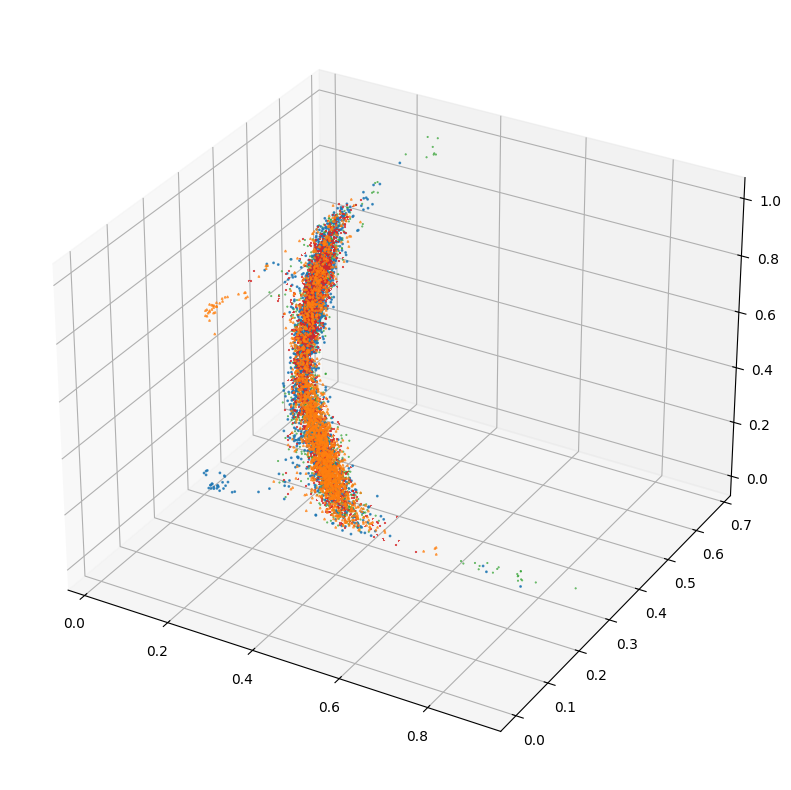

In [11]:
plot3d(dsid="e-singular", regime=50)

In [12]:
import plotly.graph_objects as go
import plotly.io as pio

def plot3dx(dsid="regular", regime=50):
  idata = posterior_samples[dsid][regime]
  fig = go.Figure()
  
  markers = ['circle', 'diamond', 'square', 'cross']
  n_chains = idata.posterior.dims["chain"]
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain, :, 0].values
    p0 = idata.posterior["p0"][chain, :].values
    p1 = idata.posterior["p1"][chain, :].values
    
    fig.add_trace(go.Scatter3d(
        x=p0, y=p1, z=w,
        mode='markers',
        marker=dict(size=1, symbol=markers[chain]),
        name=f'Chain {chain}'
    ))
  
  fig.update_layout(
      scene=dict(
          xaxis_title='p0',
          yaxis_title='p1',
          zaxis_title='w'
      )
  )
  
  # For Jupyter notebooks
  pio.renderers.default = "notebook"
  # or
  # pio.renderers.default = "iframe"
  # or for JupyterLab
  # pio.renderers.default = "jupyterlab"
  fig.update_layout(
      width=1000,
      height=800
  )
  fig.show()

In [16]:
plot3dx("e-singular", 50)

/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_20924/2356895405.py:9: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.

